RESULTS ANALYSIS --- ROUND-0 BENCHMARK

reading  outputs of round-0-bench

In [1]:
PATH = "../outputs/round-0-outp/"
RESULTS_FILE = PATH + "results__2026-9-22T3-41-4.json"
FULL_OUTPUTS_PATH = PATH + "full_outputs/"

In [56]:
results[models[0]]["gsm8k"]["gsm8k"].keys()

dict_keys(['name', 'alias', 'sample_len', 'exact_match,strict-match', 'exact_match_stderr,strict-match', 'exact_match,flexible-extract', 'exact_match_stderr,flexible-extract'])

In [ ]:
# These are different for each task, and have to be identified manually (there may be different anser extraction options)
# See full-outputs "metrics"
ACCURACY_METRICS = {
    "winogrande" :      "acc,none",
    "truthfulqa_mc2" :  "acc,none",
    "minerva_math" :    "math_verify,none",         # 
    "leaderboard_bbh" : "acc_norm,none",            
    "gsm8k" :           "exact_match,strict-match", # 
    "mmlu" :            "acc,none",                 
    "arc_challenge" :   "acc,none",                 # Because we are executing it 0-shot 
    "hellaswag" :       "acc_norm,none"             # 
}

In [93]:
import json

with open(RESULTS_FILE, "r") as f:
    results = json.load(f)
    models = list(results.keys())
TASKS = []
for model in models: TASKS += list(results[model].keys())
TASKS = set(TASKS)

print("MODELS: ")
for model in models:
    print("  • " + model, end="\n")
    for task in list(results[model].keys()):
        taskstr = task + "\1"*(20-len(task))
        print("\t|-> " + taskstr + "\t=> " + ACCURACY_METRICS[task], end="\n")
    print()

MODELS: 
  • Qwen/Qwen3.6-35B-A3B-FP8
	|-> winogrande	=> acc,none
	|-> truthfulqa_mc2	=> acc,none
	|-> minerva_math	=> math_verify,none
	|-> leaderboard_bbh	=> acc_norm,none
	|-> gsm8k	=> exact_match,strict-match
	|-> mmlu	=> acc,none
	|-> arc_challenge	=> acc,none
	|-> hellaswag	=> acc_norm,none

  • Qwen/Qwen3.8-27B-FP8
	|-> winogrande	=> acc,none
	|-> truthfulqa_mc2	=> acc,none
	|-> minerva_math	=> math_verify,none
	|-> leaderboard_bbh	=> acc_norm,none
	|-> gsm8k	=> exact_match,strict-match
	|-> mmlu	=> acc,none
	|-> arc_challenge	=> acc,none
	|-> hellaswag	=> acc_norm,none



PLOTTING THE RESULTS

In [94]:
data = {}
for task in TASKS:
    data[task] = []
    for model in models:
        if task in list(results[model].keys()):
            data[task].append(results[model][task][task][ACCURACY_METRICS[task]])
        else:
            data[task].append(0.0)

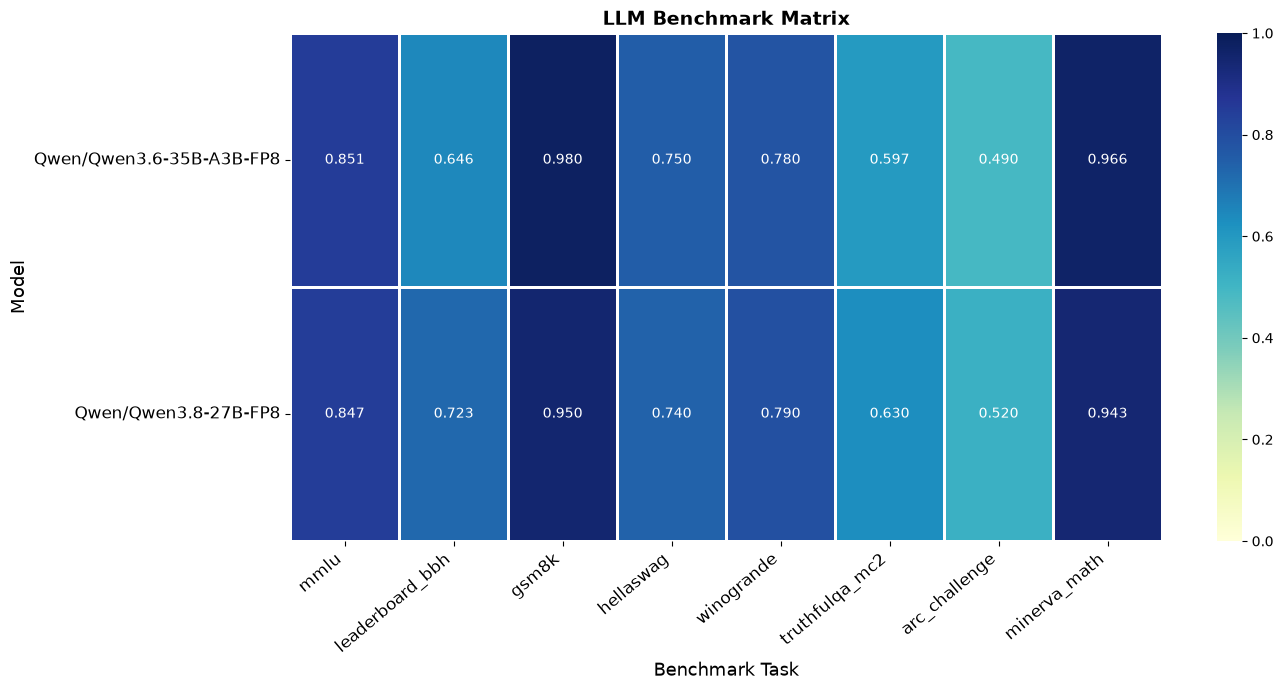

In [112]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Crea il DataFrame con Modelli sulle righe e Benchmark sulle colonne
df = pd.DataFrame(data, index=models)

# Configurazione del grafico
plt.figure(figsize=(14, 7))

# Heatmap: 'annot=True' mostra i numeri dentro le celle
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",  # 3 cifre decimali
    cmap="YlGnBu",  # Scala colori (dal giallo/verde al blu scuro)
    cbar=True,
    vmin=0.0,
    vmax=1.0,  # Limiti percentuale 0-100% (o 0-1)
    linewidths=1.0,
    square=False,
)

plt.title("LLM Benchmark Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Benchmark Task", fontsize=13)
plt.ylabel("Model", fontsize=13)
plt.xticks(rotation=40, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig("round-0-benchmark-matrix.png", dpi=300)  # Save fig
plt.show()


In [111]:
model = models[0]
task = "arc_challenge"
results[model][task][task]

# This task performs low because it's usaully evaluated in multi-shot (25-shot),
# We are running it in 0-shot
# TODO: POSSIAMO VEDERE LA VERSIONE 25-shot SI COMPORTA

{'name': 'arc_challenge',
 'alias': 'arc_challenge',
 'sample_len': 100,
 'acc,none': 0.49,
 'acc_stderr,none': 0.05024183937956912,
 'acc_norm,none': 0.4,
 'acc_norm_stderr,none': 0.04923659639173309}